# Setup

In [34]:
import mne
from mne.preprocessing import ICA
from mne_icalabel import label_components
from pathlib import Path

In [35]:
mne.viz.set_browser_backend("qt") # pip install pyqt5 mne-qt-browser
mne.set_log_level("ERROR")

In [42]:
TASK = "doors"
SFREQ_TARGET = 250.0
L_FREQ, H_FREQ = 0.1, 30.0
NOTCH_FREQ = 60.0
MASTOIDS = ["M1", "M2"]
REWP_CHAN = "FCz"
REWP_TMIN, REWP_TMAX = 0.240, 0.340
EPOCH_TMIN, EPOCH_TMAX = -0.200, 0.600
BASELINE = (-0.200, 0.0)

# Rejection thresholds (paper)
PTP_THRESH = 150e-6          # peak-to-peak, volts
GRAD_THRESH = 10e-6          # per-sample gradient at 250 Hz, volts
CHAN_REJECT_PROP = 0.10      # channel is "noisy" if >10% epochs rejected
MAX_BAD_CHANS = 3            # exclude participant if >3 noisy channels

ICA_HP = 1.0                 # high-pass for ICA fit (µ default; see notes)
ICLABEL_PROB = 0.80 

# Event coding (adjust to the actual BIDS event dictionary)
EVENT_ID = {
    ""
    "learnable/win":    11,
    "learnable/loss":   12,
    "unlearnable/win":  21,
    "unlearnable/loss": 22,
}

# Load data

In [38]:
PROJECT_PATH = Path.cwd()

DATA_DIR = "data"

raw = mne.io.read_raw_brainvision(
    PROJECT_PATH / DATA_DIR / "sub-01" / "eeg" / "sub-01_task-differentdoors_eeg.vhdr",
    preload = True
)
raw = mne.add_reference_channels(raw, ref_channels=["Fz"])
raw.set_montage("standard_1020", match_case=False, on_missing="warn")

<RawBrainVision | sub-01_task-differentdoors_eeg.eeg, 33 x 1599680 (1599.7 s), ~402.8 MiB, data loaded>

# Filter, resample, reference

In [39]:
raw.resample(SFREQ_TARGET, npad="auto")
raw.filter(
    L_FREQ,
    H_FREQ,
    method="fir",
    phase="zero",
    fir_design="firwin",
    verbose=False
)
raw.notch_filter(NOTCH_FREQ, verbose=False)

raw.set_eeg_reference(ref_channels=MASTOIDS, verbose=False)
raw.drop_channels(MASTOIDS)

<RawBrainVision | sub-01_task-differentdoors_eeg.eeg, 31 x 399920 (1599.7 s), ~94.6 MiB, data loaded>

In [28]:
raw.plot()

<RawBrainVision | sub-01_task-differentdoors_eeg.eeg, 33 x 399920 (1599.7 s), ~100.7 MiB, data loaded>

In [29]:
raw.set_eeg_reference(ref_channels=MASTOIDS, verbose=False)

<RawBrainVision | sub-01_task-differentdoors_eeg.eeg, 33 x 399920 (1599.7 s), ~100.7 MiB, data loaded>

In [40]:
raw.plot();

# ICA

In [43]:
raw_ica = raw.copy().filter(ICA_HP, None, verbose=False)
annot_bad, _ = annotate_amplitude(raw_ica, peak=1000e-6, bad_percent=50)
raw_ica.set_annotations(raw_ica.annotations + annot_bad)

<RawBrainVision | sub-01_task-differentdoors_eeg.eeg, 31 x 399920 (1599.7 s), ~94.6 MiB, data loaded>

In [45]:
n_channels = len(raw.ch_names) - len(raw.info["bads"])
rank = mne.compute_rank(raw_ica, rank="info")
print(f"n_channels (w tym Fz): {n_channels}")
print(f"Ranga danych (auto): {rank['eeg']}")

# MNE nie loguje utraty rangi na skutek refowania (?), więc:
real_rank = rank['eeg'] - 1 # Fz reference
print(f"Prawdziwa ranga danych: {real_rank}")

n_channels (w tym Fz): 31
Ranga danych (auto): 31
Prawdziwa ranga danych: 30


In [46]:
ica = ICA(
    n_components=real_rank,
    method="infomax",
    fit_params=dict(extended=True),
    random_state=97,
    max_iter="auto"
)
ica.fit(raw_ica, reject_by_annotation=True)

Method,infomax
Fit parameters,extended=Truemax_iter=500
Fit,500 iterations on raw data (399920 samples)
ICA components,30
Available PCA components,31
Channel types,eeg
ICA components marked for exclusion,—


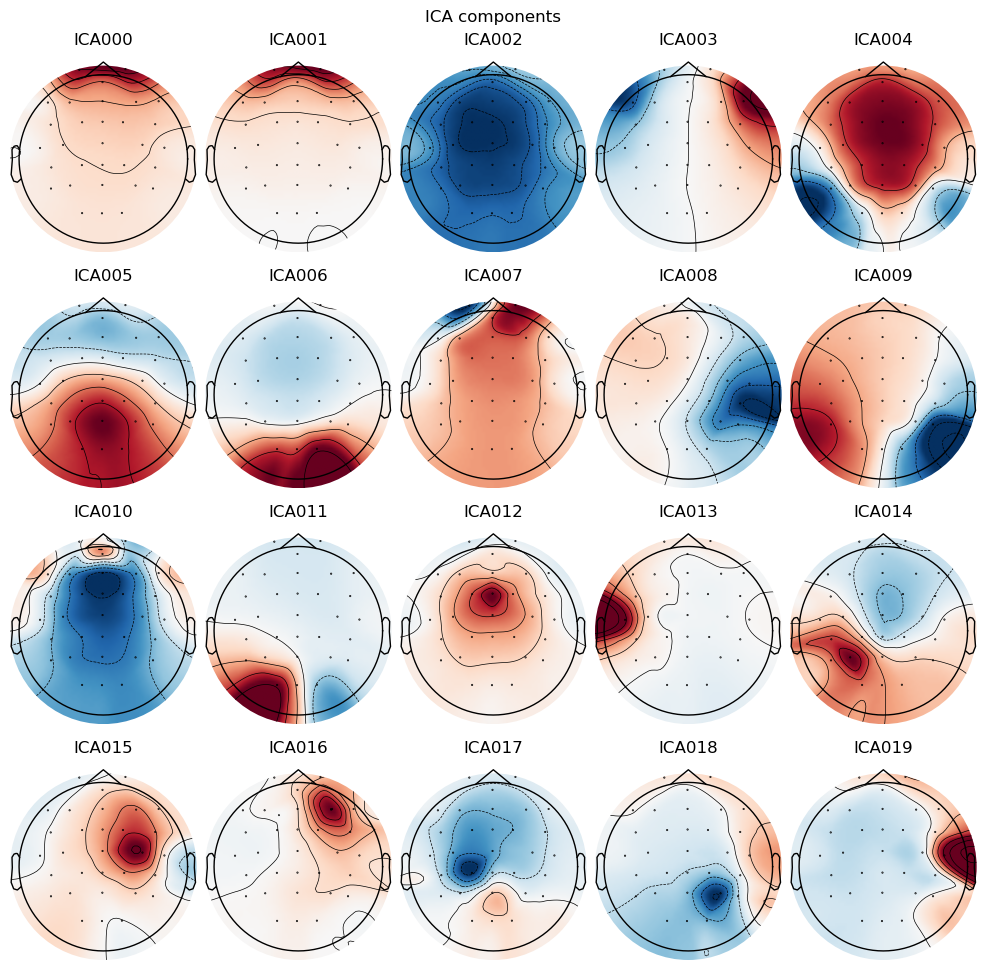

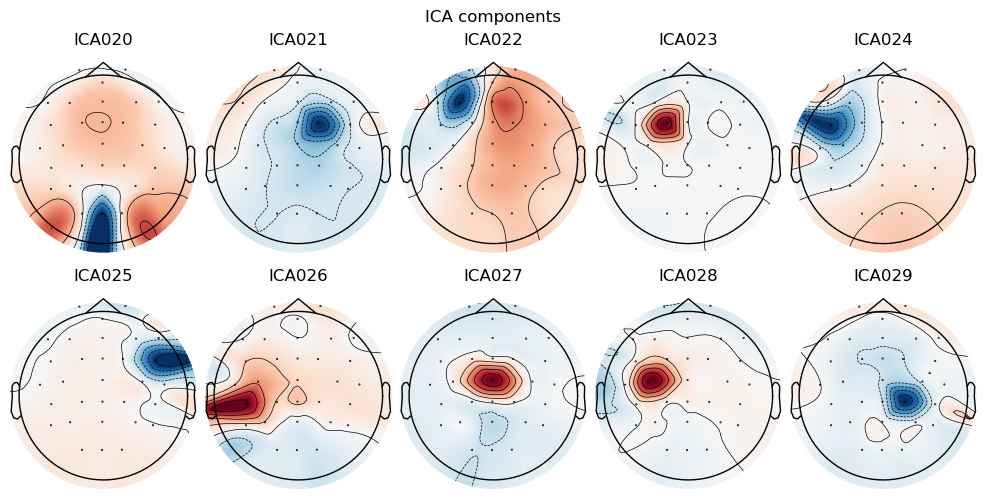

In [50]:
ica.plot_components();

In [51]:
labels = label_components(raw_ica, ica, method="iclabel")
exclude_idx = [
    i for i, (lab, prob) in enumerate(
        zip(labels["labels"], labels["y_pred_proba"]))
    if lab in ("eye blink", "muscle artifact") and prob > ICLABEL_PROB
]
ica.exclude = exclude_idx
ica.apply(raw)
print(f"ICA: removed {len(exclude_idx)} components")

ICA: removed 3 components


In [52]:
exclude_idx

[0, 1, 3]

In [53]:
raw.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x55b82e70bec0) at 0x7f9e02609a40>

In [62]:
EVENT_ID = {
    "unlearnable/win":  7,
    "unlearnable/loss": 8,
    "learnable/win":    17,
    "learnable/loss":   18,
}

ANNOT_TO_ID = {
    "Stimulus/S  7":  7,
    "Stimulus/S  8":  8,
    "Stimulus/S 17": 17,
    "Stimulus/S 18": 18,
}

events, _ = mne.events_from_annotations(raw, event_id=ANNOT_TO_ID, verbose=False)

epochs = mne.Epochs(raw, events, event_id=EVENT_ID,
                    tmin=EPOCH_TMIN, tmax=EPOCH_TMAX, baseline=BASELINE,
                    preload=True, reject=None, verbose=False)

In [63]:
data = epochs.get_data()                          # (n_ep, n_ch, n_t)
ptp = data.max(axis=2) - data.min(axis=2)         # (n_ep, n_ch)
grad = np.abs(np.diff(data, axis=2)).max(axis=2)  # (n_ep, n_ch)
bad_mask = (ptp > PTP_THRESH) | (grad > GRAD_THRESH)

chan_bad_prop = bad_mask.mean(axis=0)
noisy_chans = [epochs.ch_names[i]
               for i, p in enumerate(chan_bad_prop)
               if p > CHAN_REJECT_PROP and epochs.ch_names[i] not in MASTOIDS]

if len(noisy_chans) > MAX_BAD_CHANS:
    raise RuntimeError(
        f"sub-{SUBJECT} excluded: {len(noisy_chans)} noisy channels "
        f"(>{MAX_BAD_CHANS}).")

good_ch_idx = [i for i, ch in enumerate(epochs.ch_names)
               if ch not in noisy_chans]
drop_epoch = bad_mask[:, good_ch_idx].any(axis=1)
epochs.drop(np.where(drop_epoch)[0], reason="artifact", verbose=False)

epochs.info["bads"] = noisy_chans
epochs.interpolate_bads(reset_bads=True, verbose=False)

print(f"Noisy channels interpolated: {noisy_chans}")
print(f"Epochs dropped: {int(drop_epoch.sum())} / {len(drop_epoch)}")


Noisy channels interpolated: []
Epochs dropped: 7 / 396


/tmp/ipykernel_2244353/2441130725.py:22: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  epochs.interpolate_bads(reset_bads=True, verbose=False)


In [64]:
evokeds = {}
for cond in ("learnable", "unlearnable"):
    win = epochs[f"{cond}/win"].average()
    loss = epochs[f"{cond}/loss"].average()
    diff = mne.combine_evoked([win, loss], weights=[1, -1])
    evokeds[cond] = dict(win=win, loss=loss, diff=diff)


def mean_amp_uv(evk):
    """Mean amplitude at REWP_CHAN over the RewP window, in µV."""
    return (evk.copy().pick(REWP_CHAN)
            .crop(REWP_TMIN, REWP_TMAX).data.mean() * 1e6)


rewp_learn = mean_amp_uv(evokeds["learnable"]["diff"])
rewp_unlearn = mean_amp_uv(evokeds["unlearnable"]["diff"])
delta_rewp = rewp_learn - rewp_unlearn

print(f"RewP (learnable):   {rewp_learn:+.2f} µV")
print(f"RewP (unlearnable): {rewp_unlearn:+.2f} µV")
print(f"ΔRewP:              {delta_rewp:+.2f} µV")

RewP (learnable):   +2.88 µV
RewP (unlearnable): +3.50 µV
ΔRewP:              -0.62 µV


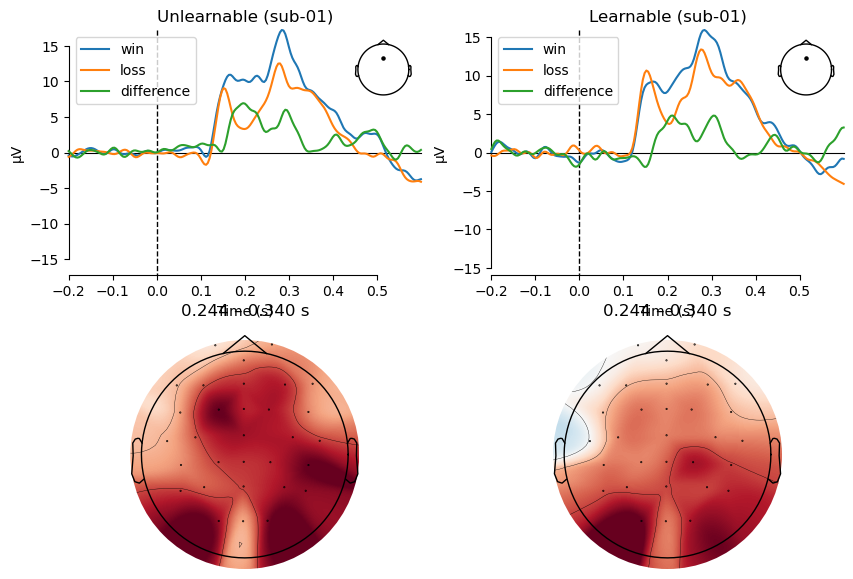

In [70]:
import matplotlib.pyplot as plt

SUBJECT="01"
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for j, cond in enumerate(("unlearnable", "learnable")):
    mne.viz.plot_compare_evokeds(
        {"win": evokeds[cond]["win"],
         "loss": evokeds[cond]["loss"],
         "difference": evokeds[cond]["diff"]},
        picks=REWP_CHAN, axes=axes[0, j], show=False,
        title=f"{cond.capitalize()} (sub-{SUBJECT})")
    evokeds[cond]["diff"].plot_topomap(
        times=[(REWP_TMIN + REWP_TMAX) / 2],
        average=REWP_TMAX - REWP_TMIN,
        axes=axes[1, j], show=False, colorbar=False)

#fig.tight_layout()
#fig.savefig(subj_deriv / f"sub-{SUBJECT}_rewp_diagnostic.png", dpi=200)
#plt.close(fig)